#**AGEN/BSEN 892 AI & Visual Intelligence in Smart Agriculture**
#**Week 5. Machine Learning IV - Neural Network**
<br/><br/>



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##MLP Classifier vs Random Forest

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay

# 1. Generate data
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)

# 4. Define models
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
mlp = MLPClassifier(hidden_layer_sizes=(10, 10),
                    activation='relu',
                    solver='adam',
                   learning_rate = 'constant',
                    learning_rate_init = 0.01,
                    batch_size = 128,
                    max_iter=1000,
                    random_state=42)

# 5. Train models
rf.fit(X_train_scaled, y_train)
mlp.fit(X_train_scaled, y_train)

# 6. Predictions
y_pred_rf = rf.predict(X_test_scaled)
y_pred_mlp = mlp.predict(X_test_scaled)

=== Random Forest ===
Accuracy: 0.97
[[97  3]
 [ 3 97]]
=== MLP Neural Network ===
Accuracy: 0.99


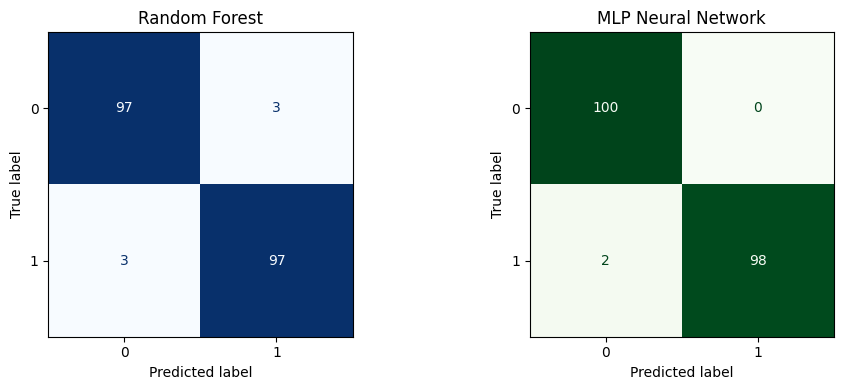

In [ ]:
# 7. Evaluation
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

print("=== MLP Neural Network ===")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Random Forest confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
axes[0].set_title("Random Forest")

# MLP confusion matrix
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp)
disp_mlp.plot(ax=axes[1], cmap=plt.cm.Greens, colorbar=False)
axes[1].set_title("MLP Neural Network")

# Adjust layout
plt.tight_layout()
plt.show()

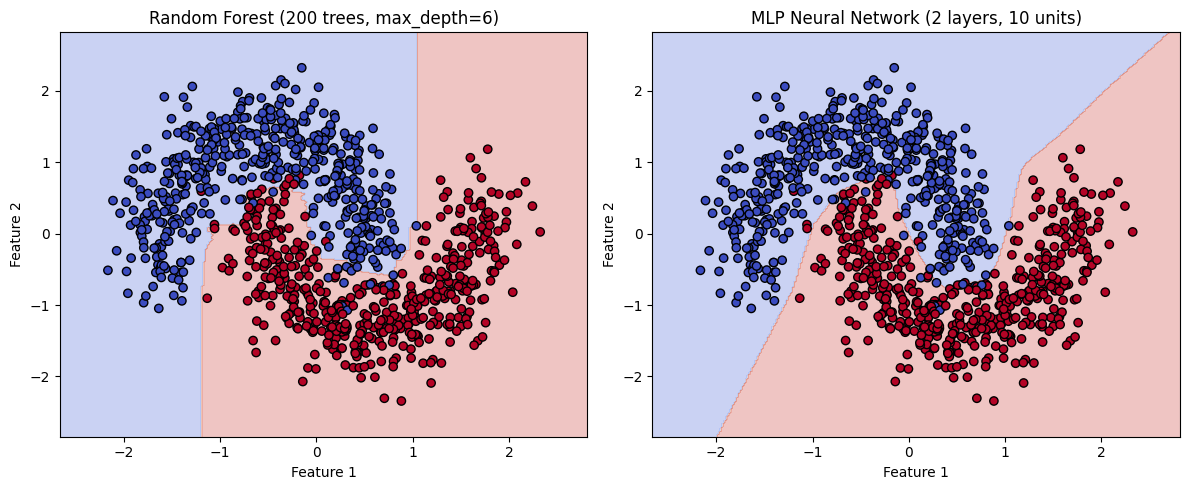

In [ ]:
# 8. Decision boundary plotting
h = .02
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_rf = rf.predict(grid).reshape(xx.shape)
Z_mlp = mlp.predict(grid).reshape(xx.shape)


plt.figure(figsize=(12, 5))
# Random Forest
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_rf, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k")
plt.title("Random Forest (200 trees, max_depth=6)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# MLP
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_mlp, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k")
plt.title("MLP Neural Network (2 layers, 10 units)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

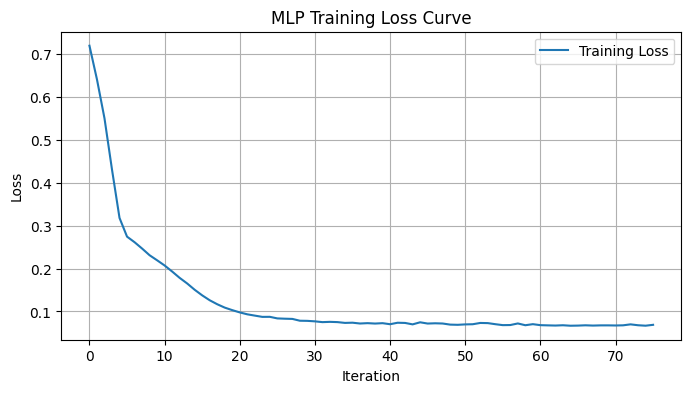

In [ ]:
# 4. Visualize loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label="Training Loss")
plt.title("MLP Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

#**Homework**
**Dataset**: Use the same dataset you applied Random Forest to in Homework 6 (i.e., MNIST dataset or your own dataset).
<br>

**Task**: Train and evaluate a MLP clasifier to recognize handwritten digits.

**Requirements**:
* Train a MLP classifier on the training set.
* Experiment with at least two different MLP structures (different hidden_layer_sizes).
* Report the performance of your model on test set. The performance must include accuracy and confusion matrix.Please also report the time spent for each parameter setting (using time.time() package).
* write a report for all the experiments you conducted, including different parameters and hidden layers you tested. Show the results and plots and discuss your findings.

You are required to submit a report document (pdf) and a colab notebook file (.ipynb).<br><br>

Pre-Class Reading:

[Convolution Neural Network](https://www.geeksforgeeks.org/machine-learning/introduction-convolution-neural-network/)

[Pytorch Introduction](https://www.geeksforgeeks.org/python/start-learning-pytorch-for-beginners/)

Shape of data: (70000, 784)
Shape of target: (70000,)
Number of classes: 10


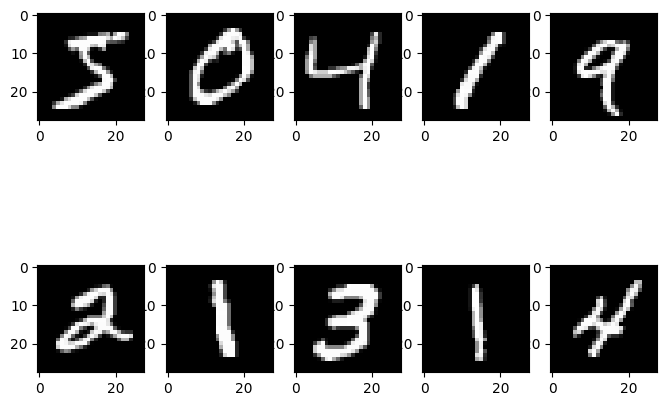

In [1]:
#choose a a Dataset: MNIST
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier

# Load MNIST data
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target

print("Shape of data:", X.shape)
print("Shape of target:", y.shape)
print("Number of classes:", len(np.unique(y)))

# Visualize dataset
plt.figure(figsize=(8, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')



In [2]:
#Train a MLP classifier on the training set
#Experiment with at least two different MLP structures (different hidden_layer_sizes)

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay # Import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split # Import train_test_split
import time # Import the time package


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scale the feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Experiment 1
mlp_1 = MLPClassifier(hidden_layer_sizes=(256, 128),
                      activation='relu',
                      solver='adam',
                      learning_rate = 'constant',
                      learning_rate_init = 0.01,
                      batch_size = 128,
                      max_iter=100, random_state=42)

#Experiment 2
mlp_2 = MLPClassifier(hidden_layer_sizes=(10, 10),
                      activation='relu',
                      solver='adam',
                      learning_rate = 'constant',
                      learning_rate_init = 0.01,
                      batch_size = 128,
                      max_iter=200, random_state=42) # Increased max_iter


#Train Model 1 and measure time
start_time_1 = time.time()
mlp_1.fit(X_train, y_train)
end_time_1 = time.time()
training_time_1 = end_time_1 - start_time_1
print(f"Experiment 1 Training Time: {training_time_1:.4f} seconds")

#Train Model 2 and measure time
start_time_2 = time.time()
mlp_2.fit(X_train, y_train)
end_time_2 = time.time()
training_time_2 = end_time_2 - start_time_2
print(f"Experiment 2 Training Time: {training_time_2:.4f} seconds")


#Predictions
y_pred_1 = mlp_1.predict(X_test)
y_pred_2 = mlp_2.predict(X_test)

#Evaluate Model
print("Experiment 1 Accuracy:", accuracy_score(y_test, y_pred_1))
print("Experiment 2 Accuracy:", accuracy_score(y_test, y_pred_2))

#classification report
print("\nExperiment 1 Classification Report:")
print(classification_report(y_test, y_pred_1))
print("\nExperiment 2 Classification Report:")
print(classification_report(y_test, y_pred_2))

Experiment 1 Training Time: 70.7670 seconds
Experiment 2 Training Time: 43.8404 seconds
Experiment 1 Accuracy: 0.9445
Experiment 2 Accuracy: 0.9302142857142857

Experiment 1 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1343
           1       0.99      0.98      0.98      1600
           2       0.95      0.93      0.94      1380
           3       0.99      0.91      0.95      1433
           4       0.99      0.94      0.96      1295
           5       0.97      0.94      0.96      1273
           6       1.00      0.92      0.96      1396
           7       0.98      0.94      0.96      1503
           8       0.71      0.97      0.82      1357
           9       0.97      0.94      0.95      1420

    accuracy                           0.94     14000
   macro avg       0.95      0.94      0.95     14000
weighted avg       0.95      0.94      0.95     14000


Experiment 2 Classification Report:
       

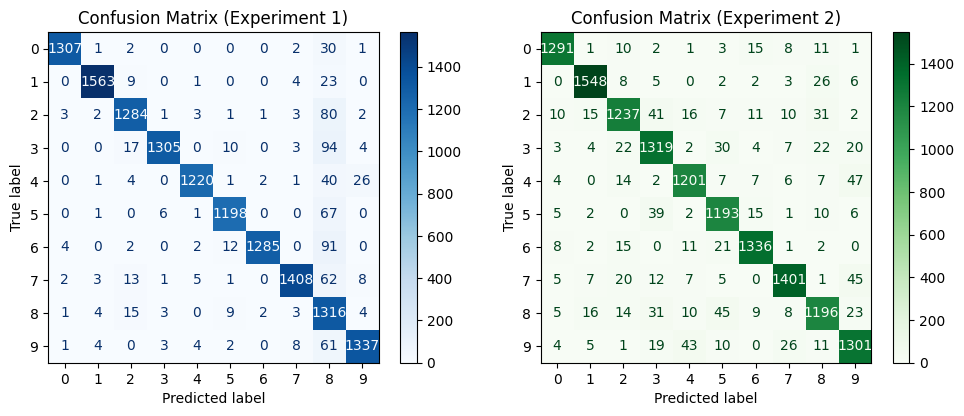

In [3]:
#Visualisation Confusion Matrix Side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix for Experiment 1
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_1, ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title("Confusion Matrix (Experiment 1)")

# Confusion matrix for Experiment 2
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_2, ax=axes[1], cmap=plt.cm.Greens)
axes[1].set_title("Confusion Matrix (Experiment 2)")

plt.tight_layout()
plt.show()

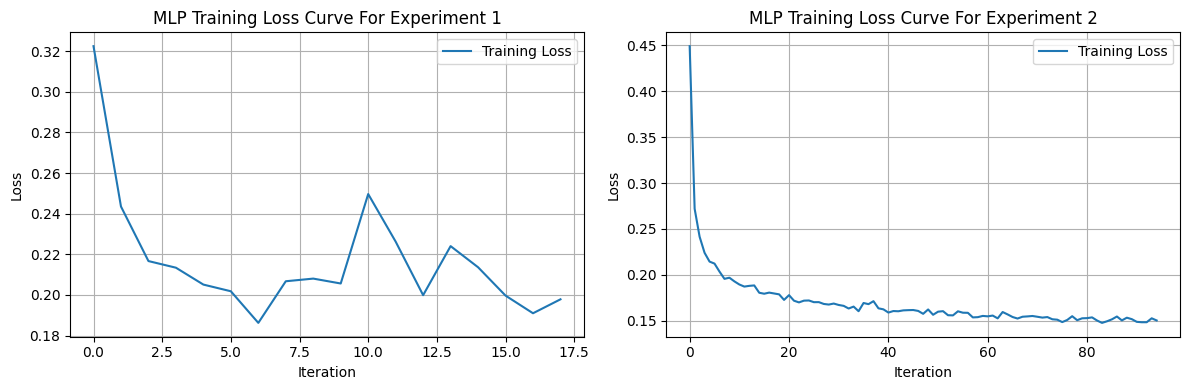

In [4]:
#loss curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MLP 1 Loss Curve
axes[0].plot(mlp_1.loss_curve_, label="Training Loss")
axes[0].set_title("MLP Training Loss Curve For Experiment 1")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# MLP 2 Loss Curve
axes[1].plot(mlp_2.loss_curve_, label="Training Loss")
axes[1].set_title("MLP Training Loss Curve For Experiment 2")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# Function to parse classification report into a DataFrame
def parse_classification_report(report):
    report_data = []
    lines = report.split('\n')
    for line in lines[2:-5]:  # Skip header and averages
        row = line.split()
        if len(row) == 5:
            class_name, precision, recall, f1_score, support = row
            report_data.append([class_name, float(precision), float(recall), float(f1_score), int(support)])
    return pd.DataFrame(report_data, columns=['class', 'precision', 'recall', 'f1-score', 'support'])

# Get classification reports as strings
report_1_str = classification_report(y_test, y_pred_1)
report_2_str = classification_report(y_test, y_pred_2)

# Parse reports into DataFrames
report_df_1 = parse_classification_report(report_1_str)
report_df_2 = parse_classification_report(report_2_str)

# Merge DataFrames for easier plotting
merged_report_df = report_df_1.merge(report_df_2, on='class', suffixes=('_exp1', '_exp2'))

display(merged_report_df)

,class,precision_exp1,recall_exp1,f1-score_exp1,support_exp1,precision_exp2,recall_exp2,f1-score_exp2,support_exp2
0,0,0.99,0.97,0.98,1343,0.97,0.96,0.96,1343
1,1,0.99,0.98,0.98,1600,0.97,0.97,0.97,1600
2,2,0.95,0.93,0.94,1380,0.92,0.90,0.91,1380
3,3,0.99,0.91,0.95,1433,0.90,0.92,0.91,1433
4,4,0.99,0.94,0.96,1295,0.93,0.93,0.93,1295
5,5,0.97,0.94,0.96,1273,0.90,0.94,0.92,1273
6,6,1.00,0.92,0.96,1396,0.95,0.96,0.96,1396
7,7,0.98,0.94,0.96,1503,0.95,0.93,0.94,1503
8,8,0.71,0.97,0.82,1357,0.91,0.88,0.89,1357
9,9,0.97,0.94,0.95,1420,0.90,0.92,0.91,1420


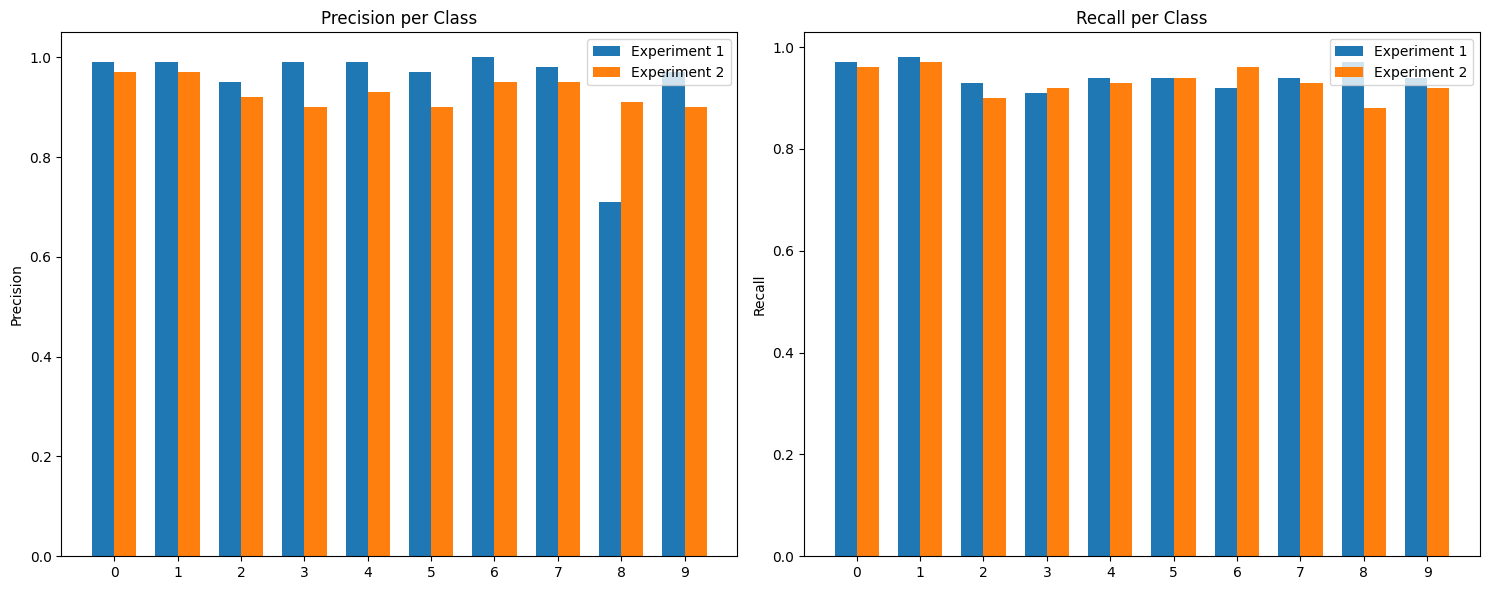

In [6]:
import matplotlib.pyplot as plt
import numpy as np

labels = merged_report_df['class']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Precision comparison
rects1 = ax1.bar(x - width/2, merged_report_df['precision_exp1'], width, label='Experiment 1')
rects2 = ax1.bar(x + width/2, merged_report_df['precision_exp2'], width, label='Experiment 2')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax1.set_ylabel('Precision')
ax1.set_title('Precision per Class')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()

# Recall comparison
rects3 = ax2.bar(x - width/2, merged_report_df['recall_exp1'], width, label='Experiment 1')
rects4 = ax2.bar(x + width/2, merged_report_df['recall_exp2'], width, label='Experiment 2')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax2.set_ylabel('Recall')
ax2.set_title('Recall per Class')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()

plt.tight_layout()
plt.show()